In [9]:
import os
import logging
import pathlib
import json
import sys
import random
import tqdm
import math
import pickle
import numpy as np
import torch
import torch.nn as nn
from libs.dataloader import build_dataloaders
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
from libauc.losses import EntLossClassification
from libauc.optimizers import SCENT
from sklearn.cluster import MiniBatchKMeans
from collections import defaultdict
from sklearn.manifold import TSNE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
data_dir = "./features/treeoflife10m_subset"

seed = 2026
device = "cuda"
feature_dim = 512
num_classes = 163002
data_size = 762654
save_frequency = 1

epochs = 20
batch_size = 128

In [3]:
def set_seed(seed):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Make cudnn deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    logging.info(f"Set random seed to {seed}")

In [4]:
set_seed(seed)
train_loader, val_loader, test_loader = build_dataloaders(data_dir, batch_size)

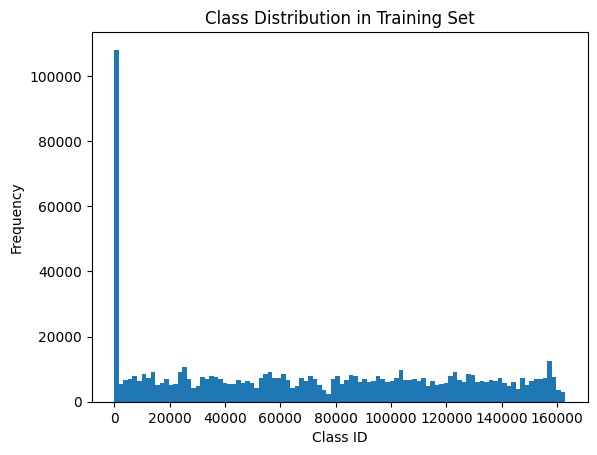

In [5]:
plt.hist(train_loader.dataset.labels.numpy(), bins=100)
plt.xlabel("Class ID")
plt.ylabel("Frequency")
plt.title("Class Distribution in Training Set")
plt.show()

In [6]:
prototypes_path = "./data/prototypes.pkl"
with open(prototypes_path, "rb") as f:
    data = pickle.load(f)
prototypes = data["prototypes"]
valid_classes = data['valid_classes']

In [7]:
class Sampler:
    def __init__(
        self,
        prototypes_path,
        num_classes,
        n_clusters=1000,
        num_negatives=1024,
        seed=0,
    ):
        if prototypes_path is None or not os.path.exists(prototypes_path):
            raise FileNotFoundError(f"Prototypes file {prototypes_path} not found.")
        with open(prototypes_path, 'rb') as f:
            data = pickle.load(f)

        self.prototypes = data['prototypes']
        valid_classes = data['valid_classes']
        print(f"Loaded prototypes from {prototypes_path}: {self.prototypes.shape}")

        self.valid_classes = np.asarray(valid_classes, dtype=np.int64)
        self.num_classes = num_classes
        self.num_negatives = num_negatives
        self.rng = np.random.default_rng(seed)

        self.kmeans = MiniBatchKMeans(
            n_clusters=n_clusters,
            batch_size=10000,
            max_iter=100,
            random_state=seed,
        )

        self.subgroup_ids = self.kmeans.fit_predict(self.prototypes)

        self.class_to_subgroup = {}
        for cls, gid in zip(self.valid_classes, self.subgroup_ids):
            self.class_to_subgroup[int(cls)] = int(gid)

        self.subgroup_to_classes = defaultdict(list)
        for cls, gid in self.class_to_subgroup.items():
            self.subgroup_to_classes[gid].append(cls)

        self.subgroup_to_classes = {
            gid: np.asarray(classes, dtype=np.int64)
            for gid, classes in self.subgroup_to_classes.items()
        }

    def lambda_schedule(self, epoch, t1=3, t2=15, lambda_max=0.7):
        if epoch <= t1:
            return 0.0
        elif epoch >= t2:
            return lambda_max
        else:
            return lambda_max * (epoch - t1) / (t2 - t1)

    def sample_classes(
        self,
        strategy,
        batch_classes,
        device,
        epoch=None,
        lambda_t=None,
        include_batch_classes=True,
        num_negatives=None,
        same_budget=False,
    ):
        """
        Returns sampled class IDs for model(..., classes=classes).

        strategy:
            "all"        -> use all classes
            "batch"      -> use only in-batch unique labels
            "global"     -> random negatives from full label space
            "local"      -> negatives from same subgroup
            "curriculum" -> mixture of global + local
        """

        if strategy == "all":
            return "all"

        if isinstance(batch_classes, torch.Tensor):
            batch_np = batch_classes.detach().cpu().numpy().astype(np.int64)
            batch_size = batch_classes.numel()
        else:
            batch_np = np.asarray(batch_classes, dtype=np.int64)
            batch_size = len(batch_np)

        batch_unique = np.unique(batch_np)
        batch_set = set(batch_unique.tolist())

        if strategy == "batch":
            return torch.as_tensor(batch_unique, dtype=torch.long, device=device)

        # decide number of negatives
        if same_budget:
            # total sampled classes ≈ batch size
            target_total_classes = batch_size
            num_neg = max(0, target_total_classes - len(batch_unique))
        else:
            # fixed number of negatives, e.g., 1024
            num_neg = self.num_negatives if num_negatives is None else num_negatives

        if strategy == "curriculum":
            if lambda_t is None:
                if epoch is None:
                    raise ValueError("For curriculum sampling, provide either epoch or lambda_t.")
                lambda_t = self.lambda_schedule(epoch)
        elif strategy == "global":
            lambda_t = 0.0
        elif strategy == "local":
            lambda_t = 1.0
        else:
            raise ValueError(f"Unknown sampling strategy: {strategy}")

        sampled = set()

        max_trials = max(1, num_neg * 10)
        trials = 0

        while len(sampled) < num_neg and trials < max_trials:
            trials += 1

            # choose one positive label from current batch
            y = int(self.rng.choice(batch_unique))

            use_local = self.rng.random() < lambda_t

            if use_local and y in self.class_to_subgroup:
                gid = self.class_to_subgroup[y]
                candidates = self.subgroup_to_classes[gid]
                neg = int(self.rng.choice(candidates))
            else:
                neg = int(self.rng.choice(self.valid_classes))

            # avoid positives and duplicates
            if neg not in batch_set:
                sampled.add(neg)

        if len(sampled) > 0:
            sampled = np.asarray(list(sampled), dtype=np.int64)

            if include_batch_classes:
                sampled_classes = np.unique(np.concatenate([batch_unique, sampled]))
            else:
                sampled_classes = np.unique(sampled)
        else:
            sampled_classes = batch_unique

        return torch.as_tensor(sampled_classes, dtype=torch.long, device=device)

In [8]:
sampler = Sampler(
    prototypes_path="./data/prototypes.pkl",
    num_classes=num_classes,
    n_clusters=1000,
    num_negatives=1024,
    seed=seed,
)

Loaded prototypes from ./data/prototypes.pkl: (78500, 512)


In [10]:
# plot the kmean clusters using t-SNE
tsne = TSNE(n_components=2, random_state=seed)
prototypes_2d = tsne.fit_transform(sampler.prototypes)

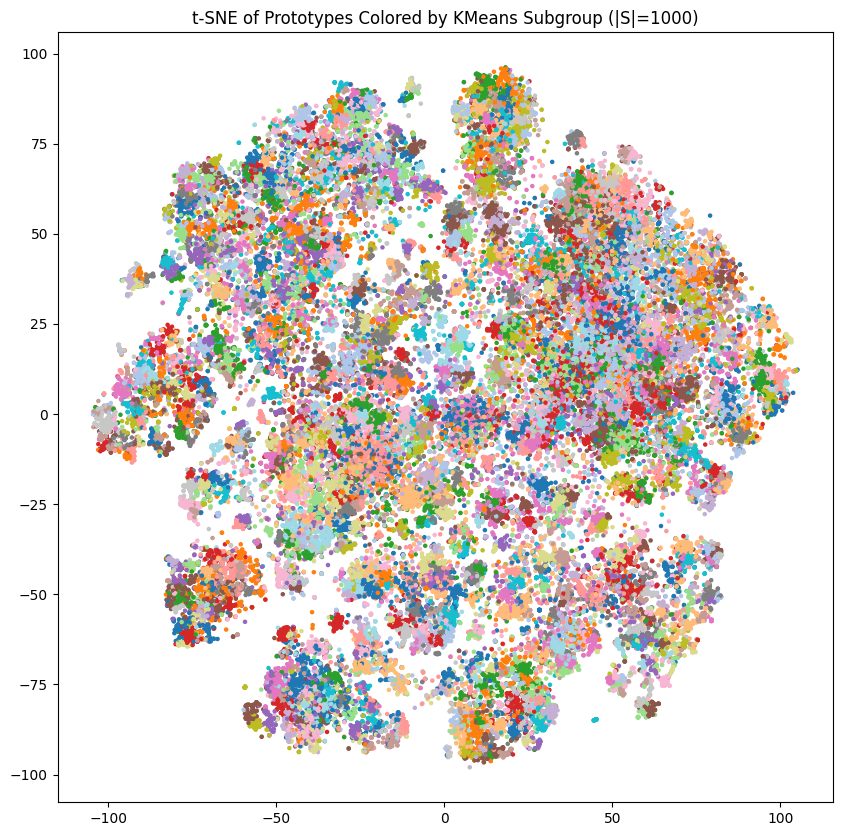

In [11]:
plt.figure(figsize=(10, 10))
scatter = plt.scatter(prototypes_2d[:, 0], prototypes_2d[:, 1], c=sampler.subgroup_ids, cmap='tab20', s=5)
plt.title("t-SNE of Prototypes Colored by KMeans Subgroup (|S|=1000)")
plt.show()

In [12]:
for epoch in range(1, epochs + 1):
    lambda_t = sampler.lambda_schedule(epoch)
    print(f"Epoch {epoch}: lambda_t = {lambda_t:.4f}")
    for i, batch in enumerate(train_loader):
        x, labels, _ = batch
        print(labels[:10])  # print first 10 labels in the batch
        sampled_classes = sampler.sample_classes(
            strategy="curriculum",
            batch_classes=labels,
            device=device,
            epoch=epoch,
            same_budget=False,
        )
        num_pos = torch.unique(labels).numel()

        print("batch_size:", labels.numel())
        print("unique labels:", torch.unique(labels).numel())
        print("returned sampled classes:", sampled_classes.numel())
        print("actual added negatives:", sampled_classes.numel() - torch.unique(labels).numel())
        break  # only do one batch for demonstration
    break  # only do one epoch for demonstration

Epoch 1: lambda_t = 0.0000


tensor([121688, 132431,  32216, 101500, 139900, 125832,      0,  33633,      0,
        111830], dtype=torch.int32)
batch_size: 128
unique labels: 100
returned sampled classes: 1124
actual added negatives: 1024


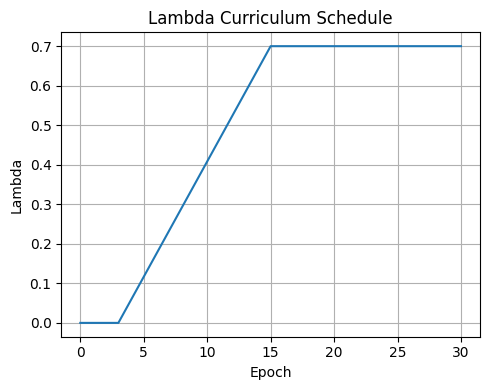

In [13]:
def lambda_schedule(epoch, t1=3, t2=15, lambda_max=0.7):
    if epoch <= t1:
        return 0.0
    elif epoch >= t2:
        return lambda_max
    else:
        return lambda_max * (epoch - t1) / (t2 - t1)

epochs = list(range(0, 31))
lambdas = [lambda_schedule(e) for e in epochs]

plt.figure(figsize=(5, 4))
plt.plot(epochs, lambdas)

plt.xlabel("Epoch")
plt.ylabel("Lambda")
plt.title("Lambda Curriculum Schedule")
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()